# Method Comparison: Neural Fiber Reconstruction

Comparing four reconstruction methods:
- **Pure MST** (`output/pure`) — baseline classical MST
- **XGB MST** (`output/xgb_mst`) — XGBoost-guided MST
- **UNet** (`output/unet_eval`) — UNet-based reconstruction
- **Hierarchical** (`output/hierarchical`) — hierarchical approach

Metric: **Average Hausdorff Distance** (lower = better)

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ── Load data ──────────────────────────────────────────────────────────────
METHODS = {
    # "skeleton":    "output/ref/skeleton/results.json",
    "mst":    "output/ref/mst/results.json",
    "Proposed":      "output/ref/annotation_grow/results.json",
    # "Hierarchical": "output/evaluation/hierarchical_0331/results.json",
    # "XGB MST":     "output/xgb_mst_eval/results.json",
    # "UNet":        "output/unet_eval/results.json",
}

ROOT = Path("/home/pony/projects/ienf_q")   # notebook is in notebooks/, data is one level up

# Pixel-to-micrometer conversion ratio per sample (μm per pixel)
with open(ROOT / "data_0510/px_um.json") as f:
    PX_UM = json.load(f)

data = {}
for name, path in METHODS.items():
    with open(ROOT / path) as f:
        data[name] = json.load(f)

# Build per-sample DataFrame
records = []
for method, d in data.items():
    for sid, s in d["samples"].items():
        records.append({
            "method": method,
            "sample": sid,
            "hausdorff": s["hausdorff_distance"],
            "hd_pred_to_gt": s["hausdorff_distance_pred_to_gt"],
            "hd_gt_to_pred": s["hausdorff_distance_gt_to_pred"],
            "hd95": s.get("hd95"),
            "hd95_pred_to_gt": s.get("hd95_pred_to_gt"),
            "hd95_gt_to_pred": s.get("hd95_gt_to_pred"),
            "cldice": s.get("cldice"),
            "cldice_tprec": s.get("cldice_tprec"),
            "cldice_tsens": s.get("cldice_tsens"),
            "nodes_pred": s["num_nodes_pred"],
            "nodes_gt": s["num_nodes_gt"],
            "edges_pred": s["num_edges_pred"],
            "edges_gt": s["num_edges_gt"],
            "components": s["num_components_pred"],
            "count_pred": s.get("valid_count_pred"),
            "count_gt": s.get("gt_count"),
            "count_error": s.get("count_error"),
        })

df = pd.DataFrame(records)

# ── Convert HD95 from pixels to micrometers ────────────────────────────────
df["px_um"] = df["sample"].map(PX_UM)
missing_ratio = df[df["px_um"].isna()]["sample"].unique()
if len(missing_ratio) > 0:
    print(f"Warning: missing px_um ratio for samples: {list(missing_ratio)}")

# for col in ["hd95", "hd95_pred_to_gt", "hd95_gt_to_pred",
#             "hausdorff", "hd_pred_to_gt", "hd_gt_to_pred"]:
#     df[f"{col}_um"] = df[col] * df["px_um"]

samples = sorted(df["sample"].unique())
methods = list(METHODS.keys())

# Color palette
COLORS = {
    "skeleton":        "#55A868",
    "mst":    "#4C72B0",
    "Proposed":      "#DD8452",
}

print(f"Loaded {len(samples)} samples × {len(methods)} methods")
summary_cols = ["hausdorff", "hd95", "cldice"]
for col in summary_cols:
    available = df[col].notna().any()
    print(f"\n{col} (available: {available})")
    if available:
        print(df.groupby("method")[col].agg(["mean","median","std"]).round(3).to_string())


Loaded 77 samples × 2 methods

hausdorff (available: True)
           mean  median    std
method                        
Proposed  0.740   0.756  0.219
mst       1.054   0.948  0.363

hd95 (available: True)
           mean  median    std
method                        
Proposed  2.471   2.308  0.945
mst       6.584   5.440  3.050

cldice (available: True)
           mean  median    std
method                        
Proposed  0.904   0.901  0.040
mst       0.865   0.873  0.047


## 1. Summary Statistics — Mean / Median / Std

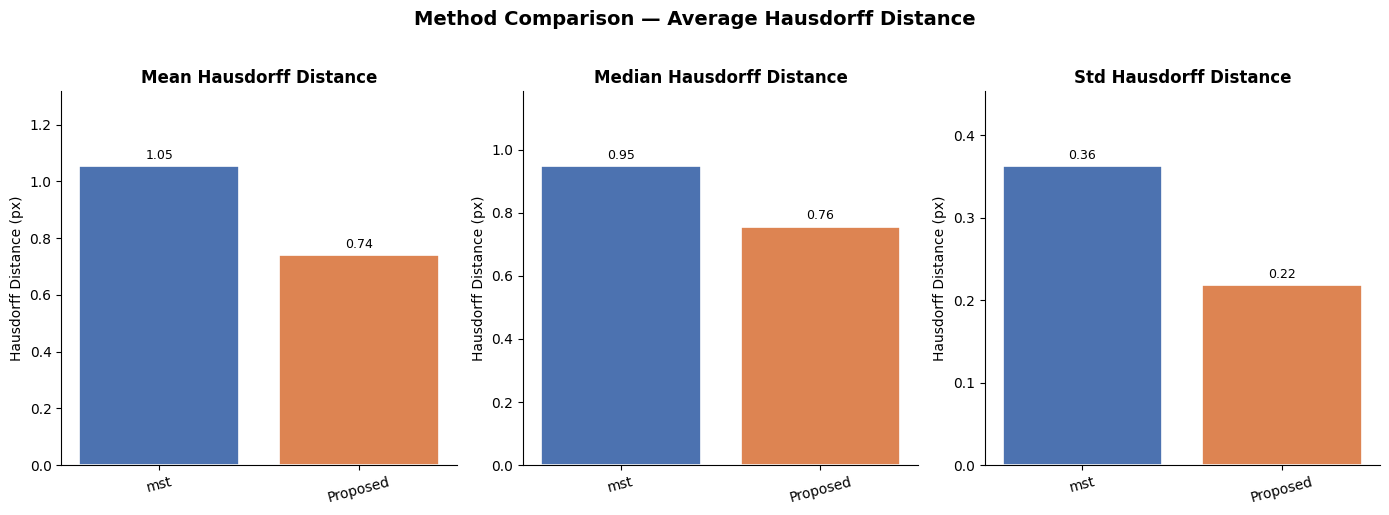

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
stats = ["mean", "median", "std"]
titles = ["Mean Hausdorff Distance", "Median Hausdorff Distance", "Std Hausdorff Distance"]

summary = df.groupby("method")["hausdorff"].agg(["mean", "median", "std"])

for ax, stat, title in zip(axes, stats, titles):
    vals = [summary.loc[m, stat] for m in methods]
    bars = ax.bar(methods, vals, color=[COLORS[m] for m in methods], edgecolor="white", linewidth=1.2)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Hausdorff Distance (px)")
    ax.set_ylim(0, max(vals) * 1.25)
    ax.tick_params(axis="x", rotation=15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Method Comparison — Average Hausdorff Distance", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 2. Box Plot — Distribution of Hausdorff Distances

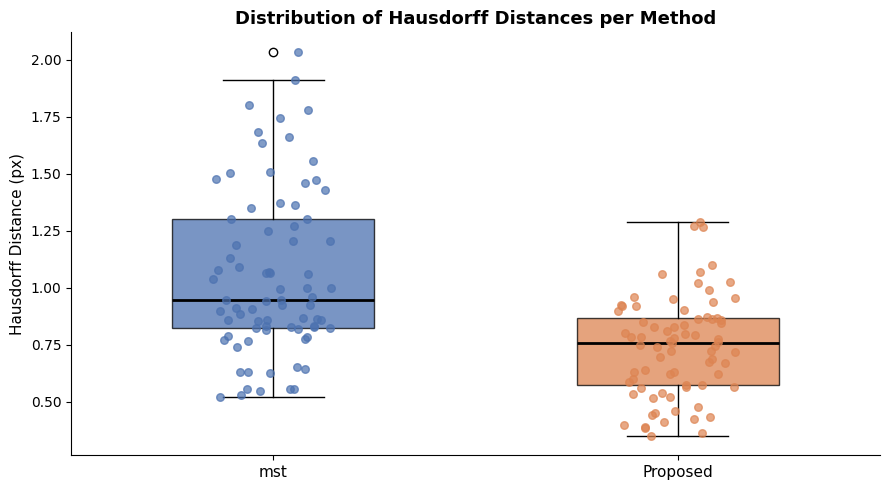

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

plot_data = [df[df["method"] == m]["hausdorff"].values for m in methods]
bp = ax.boxplot(plot_data, patch_artist=True, notch=False, widths=0.5,
                medianprops=dict(color="black", linewidth=2))

for patch, method in zip(bp["boxes"], methods):
    patch.set_facecolor(COLORS[method])
    patch.set_alpha(0.75)

# Overlay individual points
for i, (vals, method) in enumerate(zip(plot_data, methods), start=1):
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(vals))
    ax.scatter(i + jitter, vals, color=COLORS[method], s=30, alpha=0.7, zorder=3)

ax.set_xticks(range(1, len(methods) + 1))
ax.set_xticklabels(methods, fontsize=11)
ax.set_ylabel("Hausdorff Distance (px)", fontsize=11)
ax.set_title("Distribution of Hausdorff Distances per Method", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Per-Sample Hausdorff Distance (Grouped Bar)

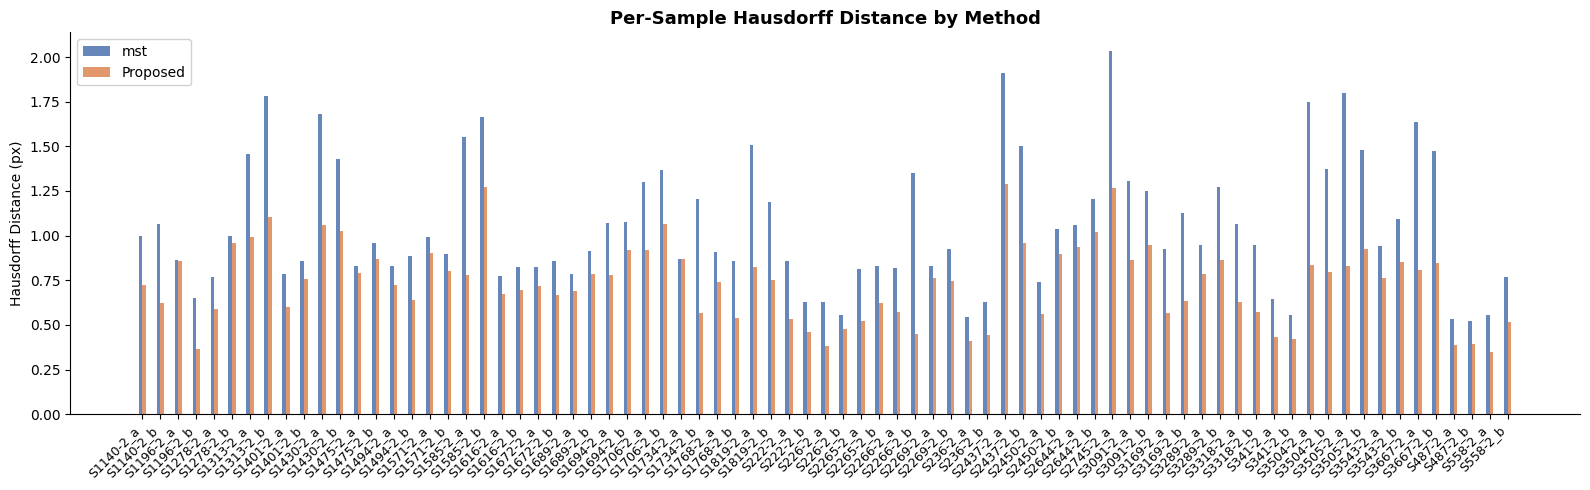

In [4]:
fig, ax = plt.subplots(figsize=(16, 5))

n_methods = len(methods)
n_samples = len(samples)
x = np.arange(n_samples)
width = 0.2

for i, method in enumerate(methods):
    subset = df[df["method"] == method].set_index("sample")
    vals = [subset.loc[s, "hausdorff"] for s in samples]
    offset = (i - n_methods / 2 + 0.5) * width
    ax.bar(x + offset, vals, width, label=method, color=COLORS[method], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(samples, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Hausdorff Distance (px)")
ax.set_title("Per-Sample Hausdorff Distance by Method", fontsize=13, fontweight="bold")
ax.legend(loc="upper left", framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Per-Sample Line Chart — Easy to Spot Winners

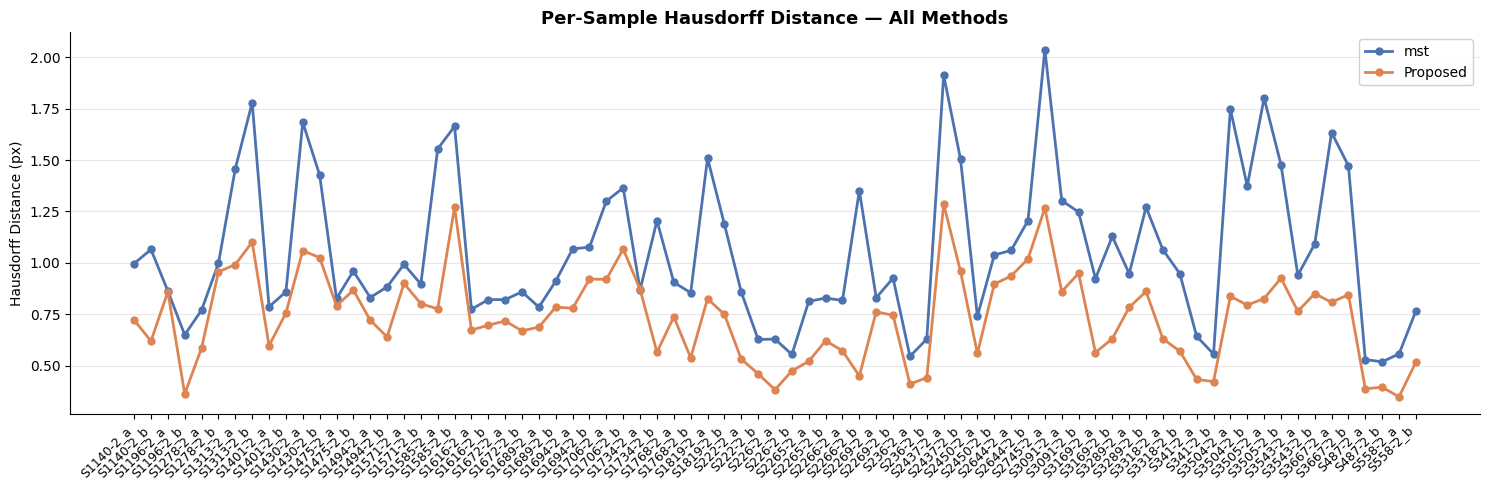

In [5]:
fig, ax = plt.subplots(figsize=(15, 5))

x = np.arange(len(samples))
for method in methods:
    subset = df[df["method"] == method].set_index("sample")
    vals = [subset.loc[s, "hausdorff"] for s in samples]
    ax.plot(x, vals, marker="o", label=method, color=COLORS[method], linewidth=2, markersize=5)

ax.set_xticks(x)
ax.set_xticklabels(samples, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Hausdorff Distance (px)")
ax.set_title("Per-Sample Hausdorff Distance — All Methods", fontsize=13, fontweight="bold")
ax.legend(framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Directional Hausdorff — Pred→GT vs GT→Pred

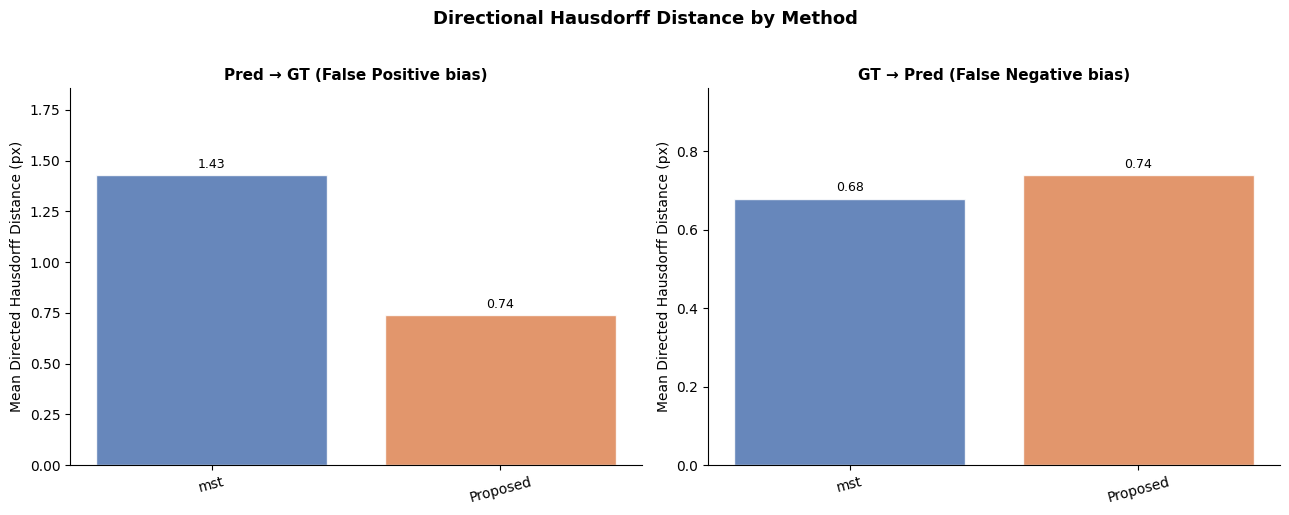

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, col, direction in zip(
    axes,
    ["hd_pred_to_gt", "hd_gt_to_pred"],
    ["Pred → GT (False Positive bias)", "GT → Pred (False Negative bias)"]
):
    vals = [df[df["method"] == m][col].mean() for m in methods]
    bars = ax.bar(methods, vals, color=[COLORS[m] for m in methods], alpha=0.85, edgecolor="white")
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
    ax.set_title(direction, fontsize=11, fontweight="bold")
    ax.set_ylabel("Mean Directed Hausdorff Distance (px)")
    ax.set_ylim(0, max(vals) * 1.3)
    ax.tick_params(axis="x", rotation=15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Directional Hausdorff Distance by Method", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 6. Graph Coverage — Predicted vs Ground Truth Nodes & Edges

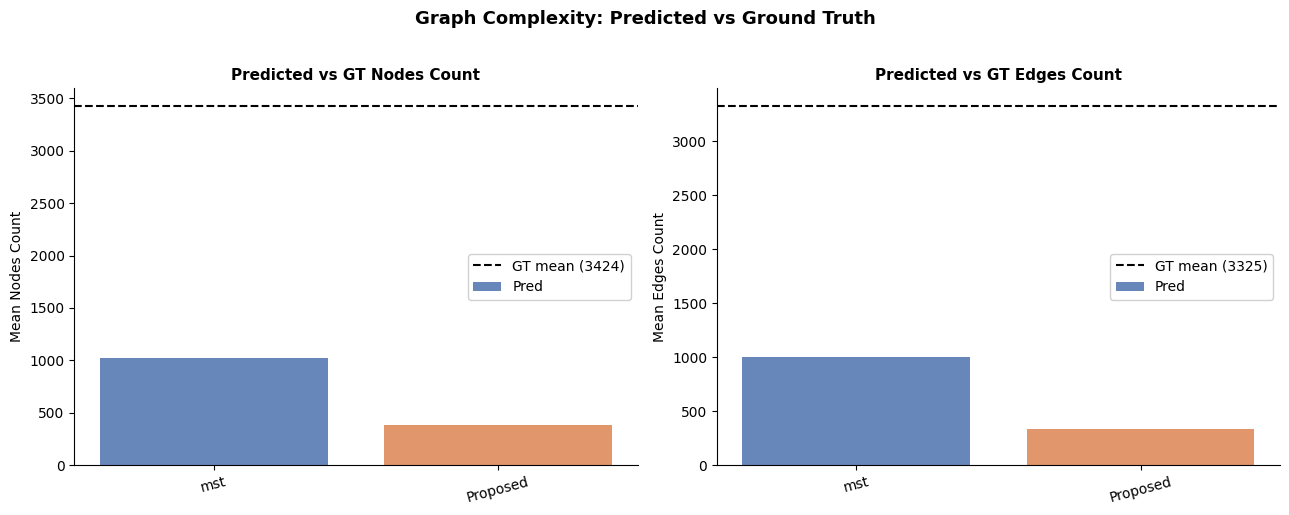

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, pred_col, gt_col, label in zip(
    axes,
    ["nodes_pred", "edges_pred"],
    ["nodes_gt", "edges_gt"],
    ["Nodes", "Edges"],
):
    gt_mean = df[df["method"] == methods[0]][gt_col].mean()  # GT is same for all
    pred_means = [df[df["method"] == m][pred_col].mean() for m in methods]

    x = np.arange(len(methods))
    ax.bar(x, pred_means, color=[COLORS[m] for m in methods], alpha=0.85, label="Pred")
    ax.axhline(gt_mean, color="black", linestyle="--", linewidth=1.5, label=f"GT mean ({gt_mean:.0f})")

    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=15)
    ax.set_ylabel(f"Mean {label} Count")
    ax.set_title(f"Predicted vs GT {label} Count", fontsize=11, fontweight="bold")
    ax.legend(framealpha=0.9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Graph Complexity: Predicted vs Ground Truth", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 7. Heatmap — Per-Sample Hausdorff Distance

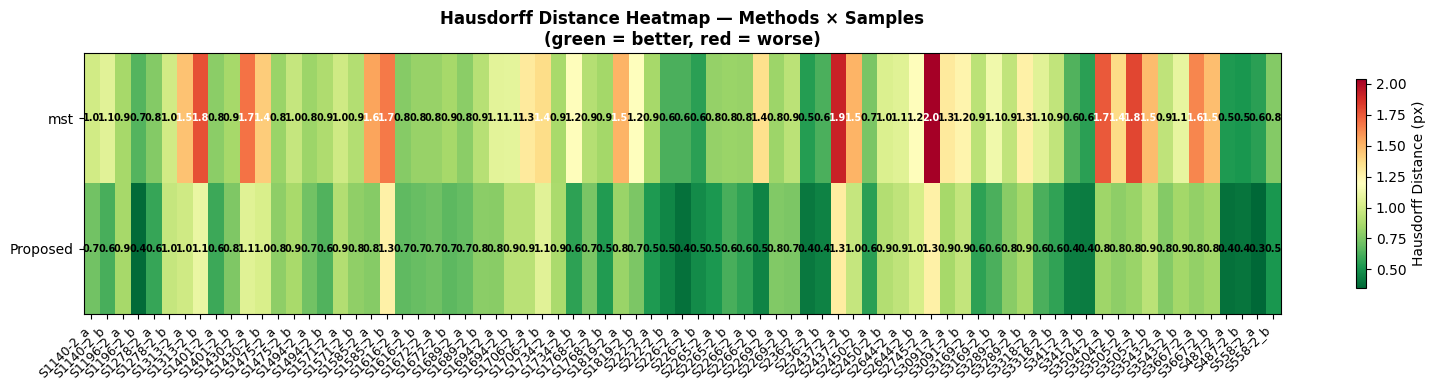

In [8]:
import matplotlib.colors as mcolors

# Build matrix: rows = methods, cols = samples
matrix = np.array([
    [df[(df["method"] == m) & (df["sample"] == s)]["hausdorff"].values[0]
     for s in samples]
    for m in methods
])

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(matrix, aspect="auto", cmap="RdYlGn_r", vmin=matrix.min(), vmax=matrix.max())

ax.set_xticks(range(len(samples)))
ax.set_xticklabels(samples, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(methods)))
ax.set_yticklabels(methods, fontsize=10)

# Annotate cells
for i in range(len(methods)):
    for j in range(len(samples)):
        val = matrix[i, j]
        # Use white text on dark cells
        norm_val = (val - matrix.min()) / (matrix.max() - matrix.min())
        text_color = "white" if norm_val > 0.6 else "black"
        ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                fontsize=7, color=text_color, fontweight="bold")

plt.colorbar(im, ax=ax, label="Hausdorff Distance (px)", shrink=0.8)
ax.set_title("Hausdorff Distance Heatmap — Methods × Samples\n(green = better, red = worse)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Rank Analysis — How Often Each Method Wins

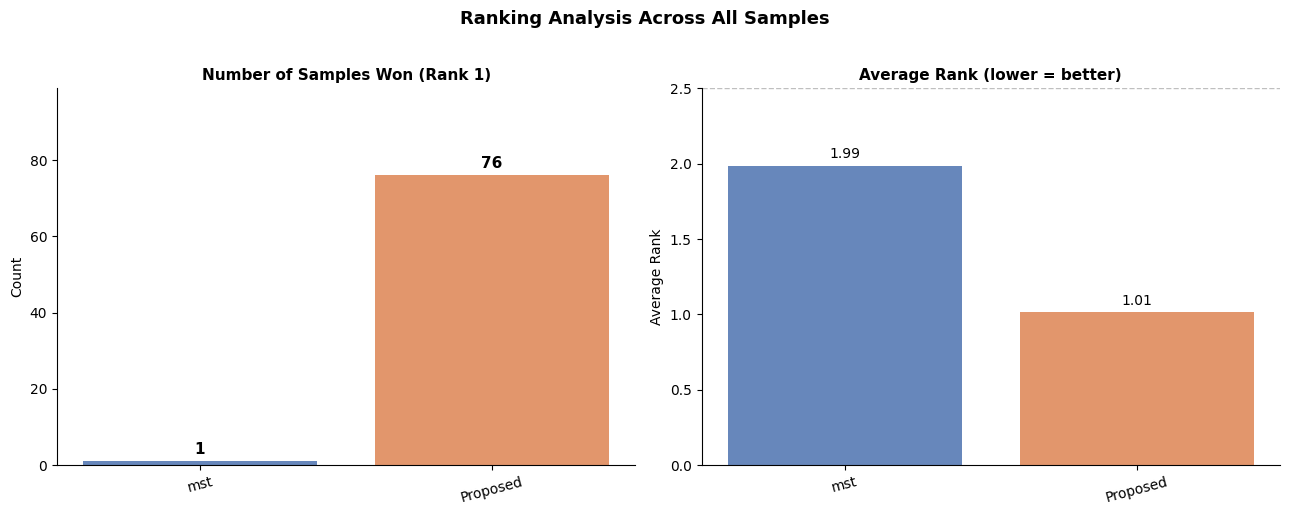


Full ranking summary:
Proposed    1.012987
mst         1.987013


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Rank 1 wins ──
wins = {m: 0 for m in methods}
for s in samples:
    sample_vals = {m: df[(df["method"] == m) & (df["sample"] == s)]["hausdorff"].values[0]
                   for m in methods}
    winner = min(sample_vals, key=sample_vals.get)
    wins[winner] += 1

ax = axes[0]
bars = ax.bar(methods, [wins[m] for m in methods],
              color=[COLORS[m] for m in methods], alpha=0.85)
ax.bar_label(bars, padding=3, fontsize=11, fontweight="bold")
ax.set_title("Number of Samples Won (Rank 1)", fontsize=11, fontweight="bold")
ax.set_ylabel("Count")
ax.set_ylim(0, max(wins.values()) * 1.3)
ax.tick_params(axis="x", rotation=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── Average rank ──
ranks_df = pd.DataFrame({
    m: [df[(df["method"] == m) & (df["sample"] == s)]["hausdorff"].values[0]
        for s in samples]
    for m in methods
}, index=samples)
avg_ranks = ranks_df.rank(axis=1).mean()

ax = axes[1]
bars = ax.bar(methods, [avg_ranks[m] for m in methods],
              color=[COLORS[m] for m in methods], alpha=0.85)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=10)
ax.set_title("Average Rank (lower = better)", fontsize=11, fontweight="bold")
ax.set_ylabel("Average Rank")
ax.set_ylim(0, len(methods) + 0.5)
ax.axhline(2.5, color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.tick_params(axis="x", rotation=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.suptitle("Ranking Analysis Across All Samples", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nFull ranking summary:")
print(avg_ranks.sort_values().to_string())

---
## HD95 Analysis — 95th Percentile Hausdorff Distance

**HD95** is the 95th percentile of the per-point minimum distances between predicted and GT skeletons.  
It is more robust than max Hausdorff: the worst 5% of outlier points are excluded.

- `hd95` — `max(p95(pred→GT), p95(GT→pred))` (lower = better)
- `hd95_pred_to_gt` — 95th percentile of distances from each pred point to nearest GT point
- `hd95_gt_to_pred` — 95th percentile of distances from each GT point to nearest pred point

### HD95-1. Summary Statistics — Mean / Median / Std

Samples with HD95: 77
            mean  median     std
method                          
Proposed  2.4705  2.3076  0.9445
mst       6.5840  5.4400  3.0503


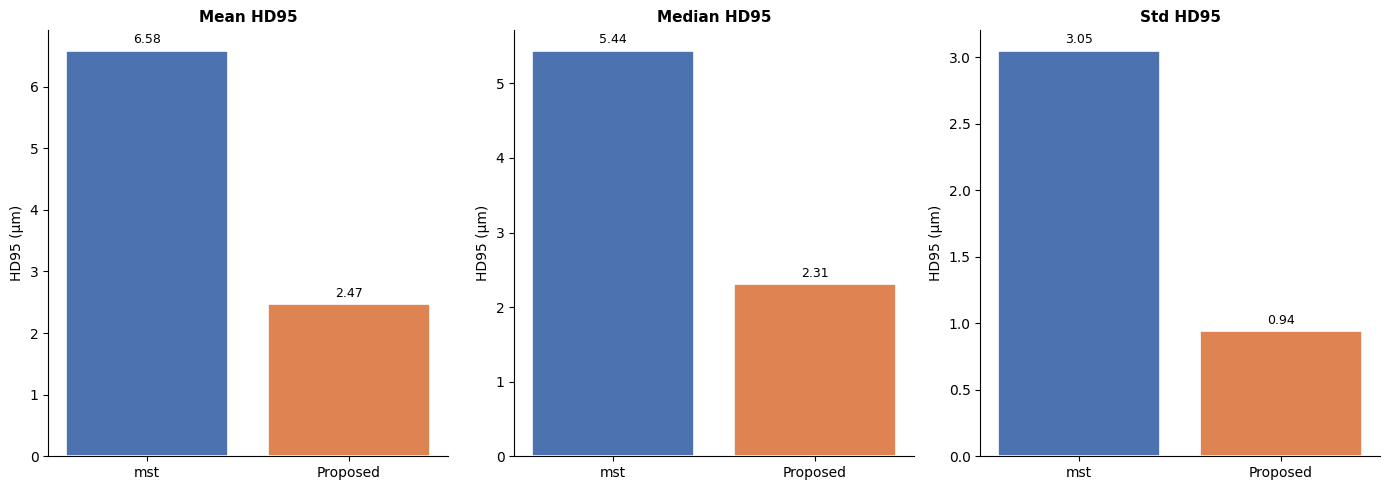

In [10]:
df_hd95 = df[df["hd95"].notna()].copy()
hd95_methods = [m for m in methods if df_hd95[df_hd95["method"] == m]["hd95"].notna().any()]

if df_hd95.empty:
    print("No HD95 data available — re-run evaluation with updated evaluate_dataset.py.")
else:
    hd95_summary = df_hd95.groupby("method")["hd95"].agg(["mean", "median", "std"]).round(4)
    print(f"Samples with HD95: {df_hd95['sample'].nunique()}")
    print(hd95_summary)

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    stats  = ["mean", "median", "std"]
    titles = ["Mean HD95", "Median HD95", "Std HD95"]

    for ax, stat, title in zip(axes, stats, titles):
        vals = [hd95_summary.loc[m, stat] for m in hd95_methods]
        bars = ax.bar(hd95_methods, vals, color=[COLORS[m] for m in hd95_methods],
                      edgecolor="white", linewidth=1.2)
        ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.set_ylabel("HD95 (μm)")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # plt.suptitle("HD95 Summary Statistics", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


### HD95-2. Box Plot — Distribution of HD95

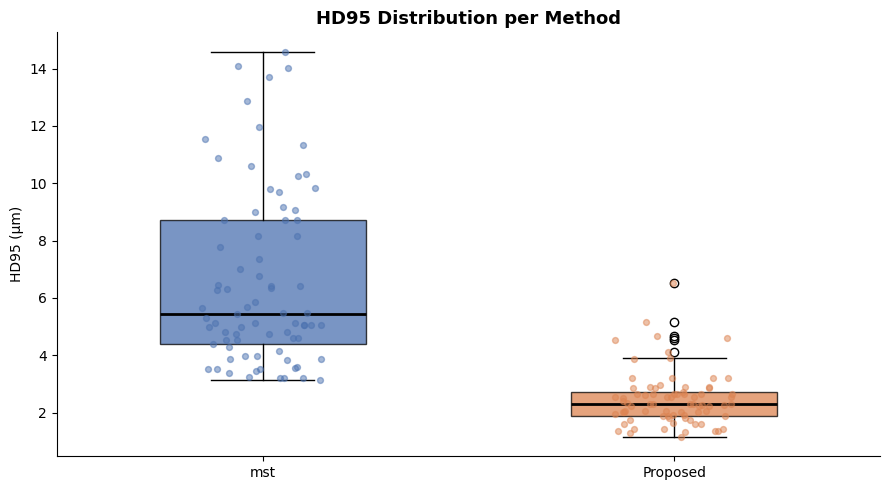

In [11]:
if not df_hd95.empty:
    fig, ax = plt.subplots(figsize=(9, 5))

    plot_data = [df_hd95[df_hd95["method"] == m]["hd95"].dropna().values for m in hd95_methods]
    bp = ax.boxplot(plot_data, patch_artist=True, notch=False, widths=0.5,
                    medianprops=dict(color="black", linewidth=2))

    for patch, method in zip(bp["boxes"], hd95_methods):
        patch.set_facecolor(COLORS[method])
        patch.set_alpha(0.75)

    rng = np.random.default_rng(42)
    for i, (vals, method) in enumerate(zip(plot_data, hd95_methods), start=1):
        jitter = rng.uniform(-0.15, 0.15, size=len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color=COLORS[method], alpha=0.5, s=18, zorder=3)

    ax.set_xticks(range(1, len(hd95_methods) + 1))
    ax.set_xticklabels(hd95_methods, fontsize=10)
    ax.set_ylabel("HD95 (μm)")
    ax.set_title("HD95 Distribution per Method", fontsize=13, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()


### HD95-3. Per-Sample HD95 (Grouped Bar)

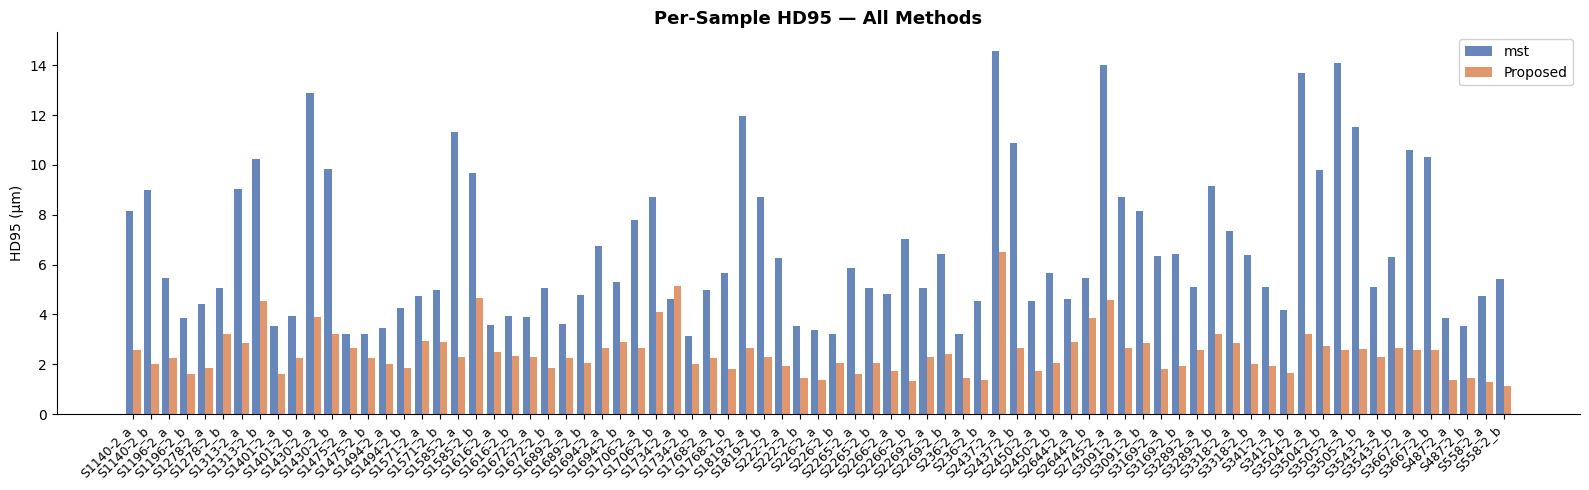

In [12]:
if not df_hd95.empty:
    hd95_samples = sorted(df_hd95["sample"].unique())
    fig, ax = plt.subplots(figsize=(16, 5))

    n_methods = len(hd95_methods)
    x = np.arange(len(hd95_samples))
    width = 0.8 / n_methods

    for i, method in enumerate(hd95_methods):
        subset = df_hd95[df_hd95["method"] == method].set_index("sample")
        vals = [subset.loc[s, "hd95"] if s in subset.index else np.nan for s in hd95_samples]
        offset = (i - n_methods / 2 + 0.5) * width
        ax.bar(x + offset, vals, width, label=method, color=COLORS[method], alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(hd95_samples, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("HD95 (μm)")
    ax.set_title("Per-Sample HD95 — All Methods", fontsize=13, fontweight="bold")
    ax.legend(framealpha=0.9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()


### HD95-4. Directional HD95 — Pred→GT vs GT→Pred

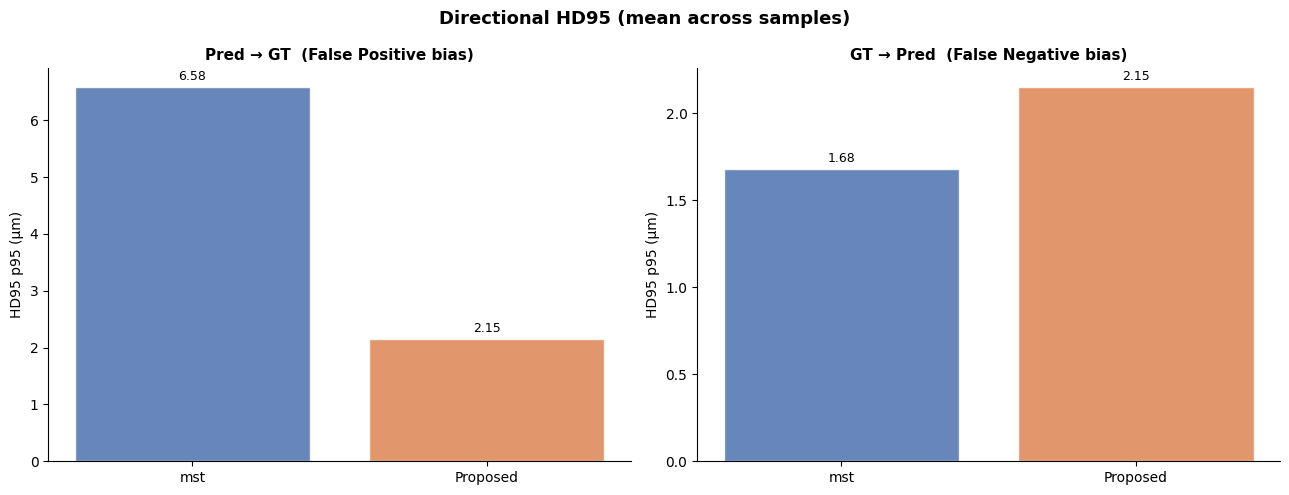

In [13]:
if not df_hd95.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

    for ax, col, direction in zip(
        axes,
        ["hd95_pred_to_gt", "hd95_gt_to_pred"],
        ["Pred → GT  (False Positive bias)", "GT → Pred  (False Negative bias)"]
    ):
        vals = [df_hd95[df_hd95["method"] == m][col].mean() for m in hd95_methods]
        bars = ax.bar(hd95_methods, vals, color=[COLORS[m] for m in hd95_methods],
                      alpha=0.85, edgecolor="white")
        ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
        ax.set_title(direction, fontsize=11, fontweight="bold")
        ax.set_ylabel("HD95 p95 (μm)")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.suptitle("Directional HD95 (mean across samples)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


### HD95-5. Heatmap — Per-Sample HD95

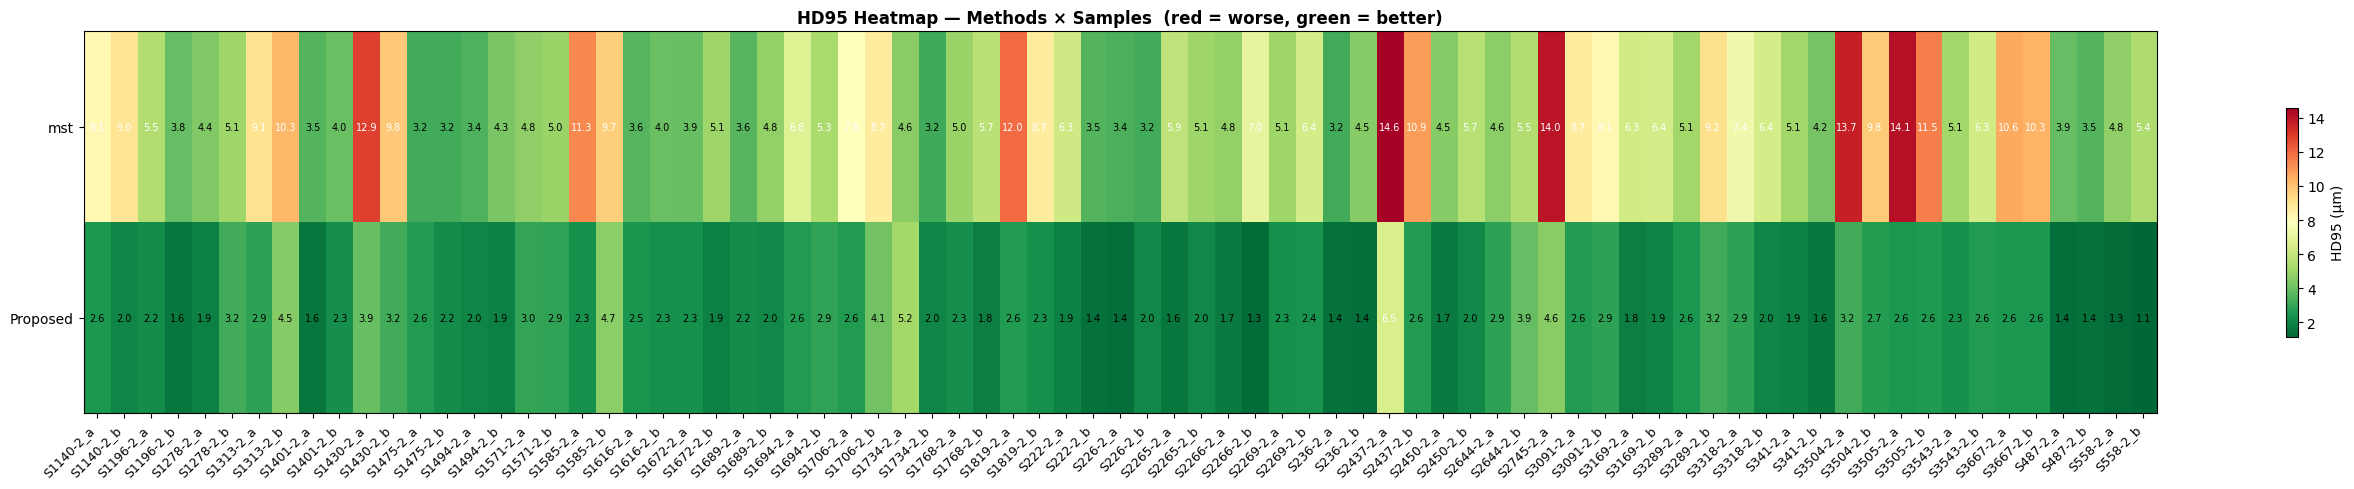

In [14]:
if not df_hd95.empty:
    import matplotlib.colors as mcolors

    hd95_samples = sorted(df_hd95["sample"].unique())
    matrix = np.full((len(hd95_methods), len(hd95_samples)), np.nan)
    for i, m in enumerate(hd95_methods):
        for j, s in enumerate(hd95_samples):
            val = df_hd95[(df_hd95["method"] == m) & (df_hd95["sample"] == s)]["hd95"]
            if not val.empty and not val.isna().all():
                matrix[i, j] = val.values[0]

    fig, ax = plt.subplots(figsize=(max(16, len(hd95_samples) * 0.35), 3 + len(hd95_methods)))
    im = ax.imshow(matrix, aspect="auto", cmap="RdYlGn_r",
                   vmin=np.nanmin(matrix), vmax=np.nanmax(matrix))

    ax.set_xticks(range(len(hd95_samples)))
    ax.set_xticklabels(hd95_samples, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(hd95_methods)))
    ax.set_yticklabels(hd95_methods, fontsize=10)
    ax.set_title("HD95 Heatmap — Methods × Samples  (red = worse, green = better)",
                 fontsize=12, fontweight="bold")

    for i in range(len(hd95_methods)):
        for j in range(len(hd95_samples)):
            val = matrix[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=7,
                        color="black" if val < np.nanmedian(matrix) * 1.5 else "white")

    plt.colorbar(im, ax=ax, label="HD95 (μm)", shrink=0.6)
    plt.tight_layout()
    plt.show()


---
## clDice Analysis — Centerline Dice Similarity

**clDice** measures topology-preserving overlap between predicted and GT skeletons.
- `cldice` — harmonic mean of precision and sensitivity (higher = better, range 0–1)
- `cldice_tprec` — topology precision: how much of the predicted skeleton is covered by GT
- `cldice_tsens` — topology sensitivity: how much of the GT skeleton is covered by prediction

Only samples with GT label are included.

### 9. clDice Summary Statistics

Samples with clDice: 77
            mean  median     std
method                          
Proposed  0.9042  0.9014  0.0398
mst       0.8654  0.8729  0.0474


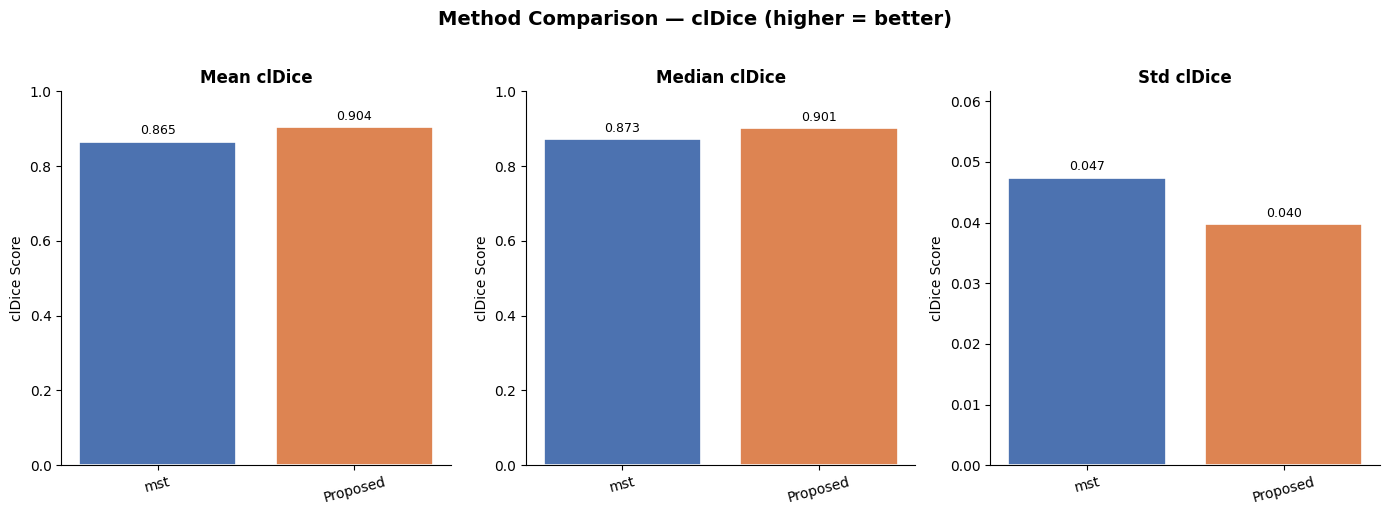

In [15]:
df_cld = df[df["cldice"].notna()].copy()
cld_methods = [m for m in methods if df_cld[df_cld["method"] == m]["cldice"].notna().any()]

if df_cld.empty:
    print("No clDice data available (GT labels missing from all evaluated results).")
else:
    cld_summary = df_cld.groupby("method")["cldice"].agg(["mean", "median", "std"]).round(4)
    print(f"Samples with clDice: {df_cld['sample'].nunique()}")
    print(cld_summary)

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    stats  = ["mean", "median", "std"]
    titles = ["Mean clDice", "Median clDice", "Std clDice"]

    for ax, stat, title in zip(axes, stats, titles):
        vals = [cld_summary.loc[m, stat] if m in cld_summary.index else 0 for m in cld_methods]
        bars = ax.bar(cld_methods, vals, color=[COLORS[m] for m in cld_methods],
                      edgecolor="white", linewidth=1.2)
        ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_ylabel("clDice Score")
        ax.set_ylim(0, min(1.0, max(vals) * 1.3) if vals else 1.0)
        ax.tick_params(axis="x", rotation=15)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.suptitle("Method Comparison — clDice (higher = better)", fontsize=14,
                 fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

### 10. clDice Distribution (Box Plot)

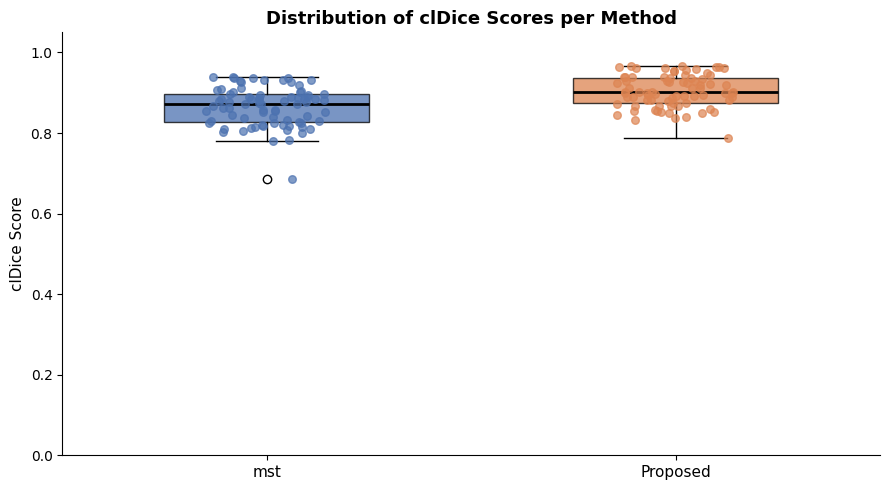

In [16]:
if not df_cld.empty:
    fig, ax = plt.subplots(figsize=(9, 5))

    plot_data = [df_cld[df_cld["method"] == m]["cldice"].dropna().values for m in cld_methods]
    bp = ax.boxplot(plot_data, patch_artist=True, notch=False, widths=0.5,
                    medianprops=dict(color="black", linewidth=2))

    for patch, method in zip(bp["boxes"], cld_methods):
        patch.set_facecolor(COLORS[method])
        patch.set_alpha(0.75)

    rng = np.random.default_rng(42)
    for i, (vals, method) in enumerate(zip(plot_data, cld_methods), start=1):
        jitter = rng.uniform(-0.15, 0.15, len(vals))
        ax.scatter(i + jitter, vals, color=COLORS[method], s=30, alpha=0.7, zorder=3)

    ax.set_xticks(range(1, len(cld_methods) + 1))
    ax.set_xticklabels(cld_methods, fontsize=11)
    ax.set_ylabel("clDice Score", fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_title("Distribution of clDice Scores per Method", fontsize=13, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

### 11. clDice Components — Precision vs Sensitivity

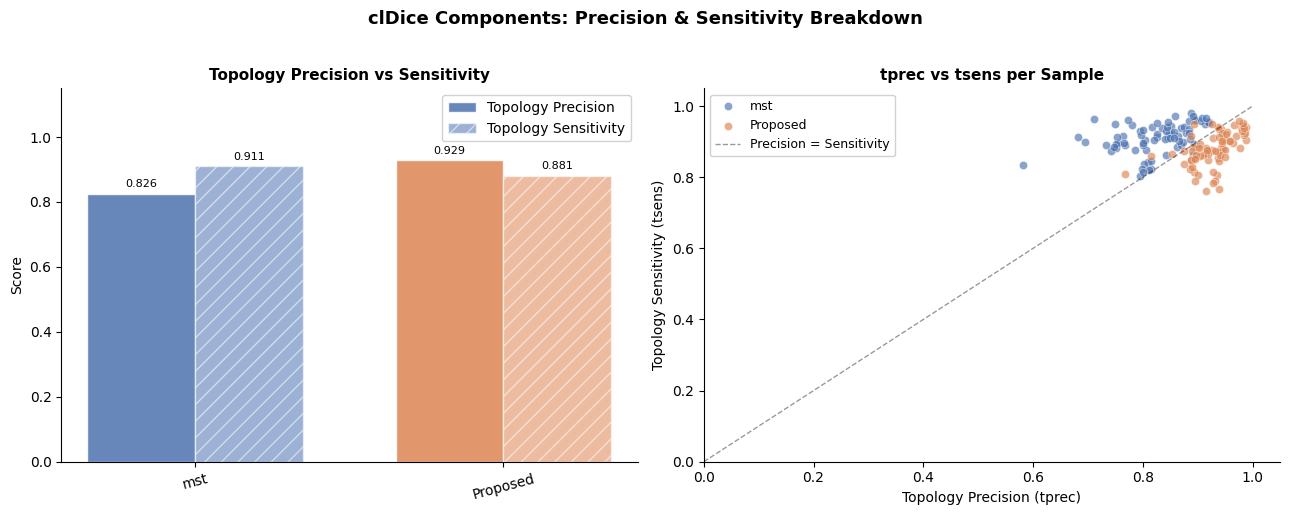

In [17]:
if not df_cld.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # ── Left: grouped bar — mean tprec and tsens per method ──
    ax = axes[0]
    x = np.arange(len(cld_methods))
    w = 0.35
    tprec_means = [df_cld[df_cld["method"] == m]["cldice_tprec"].mean() for m in cld_methods]
    tsens_means = [df_cld[df_cld["method"] == m]["cldice_tsens"].mean() for m in cld_methods]

    bars_p = ax.bar(x - w / 2, tprec_means, w, label="Topology Precision", alpha=0.85,
                    color=[COLORS[m] for m in cld_methods], edgecolor="white")
    bars_s = ax.bar(x + w / 2, tsens_means, w, label="Topology Sensitivity", alpha=0.55,
                    color=[COLORS[m] for m in cld_methods], edgecolor="white", hatch="//")
    ax.bar_label(bars_p, fmt="%.3f", padding=3, fontsize=8)
    ax.bar_label(bars_s, fmt="%.3f", padding=3, fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(cld_methods, rotation=15)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.15)
    ax.set_title("Topology Precision vs Sensitivity", fontsize=11, fontweight="bold")
    ax.legend(framealpha=0.9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # ── Right: scatter tprec vs tsens per sample ──
    ax = axes[1]
    for method in cld_methods:
        sub = df_cld[df_cld["method"] == method].dropna(subset=["cldice_tprec", "cldice_tsens"])
        ax.scatter(sub["cldice_tprec"], sub["cldice_tsens"],
                   label=method, color=COLORS[method], alpha=0.65, s=35,
                   edgecolors="white", linewidths=0.4)
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.4, label="Precision = Sensitivity")
    ax.set_xlabel("Topology Precision (tprec)", fontsize=10)
    ax.set_ylabel("Topology Sensitivity (tsens)", fontsize=10)
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.set_title("tprec vs tsens per Sample", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9, framealpha=0.9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.suptitle("clDice Components: Precision & Sensitivity Breakdown", fontsize=13,
                 fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

### 12. clDice Heatmap — Methods × Samples

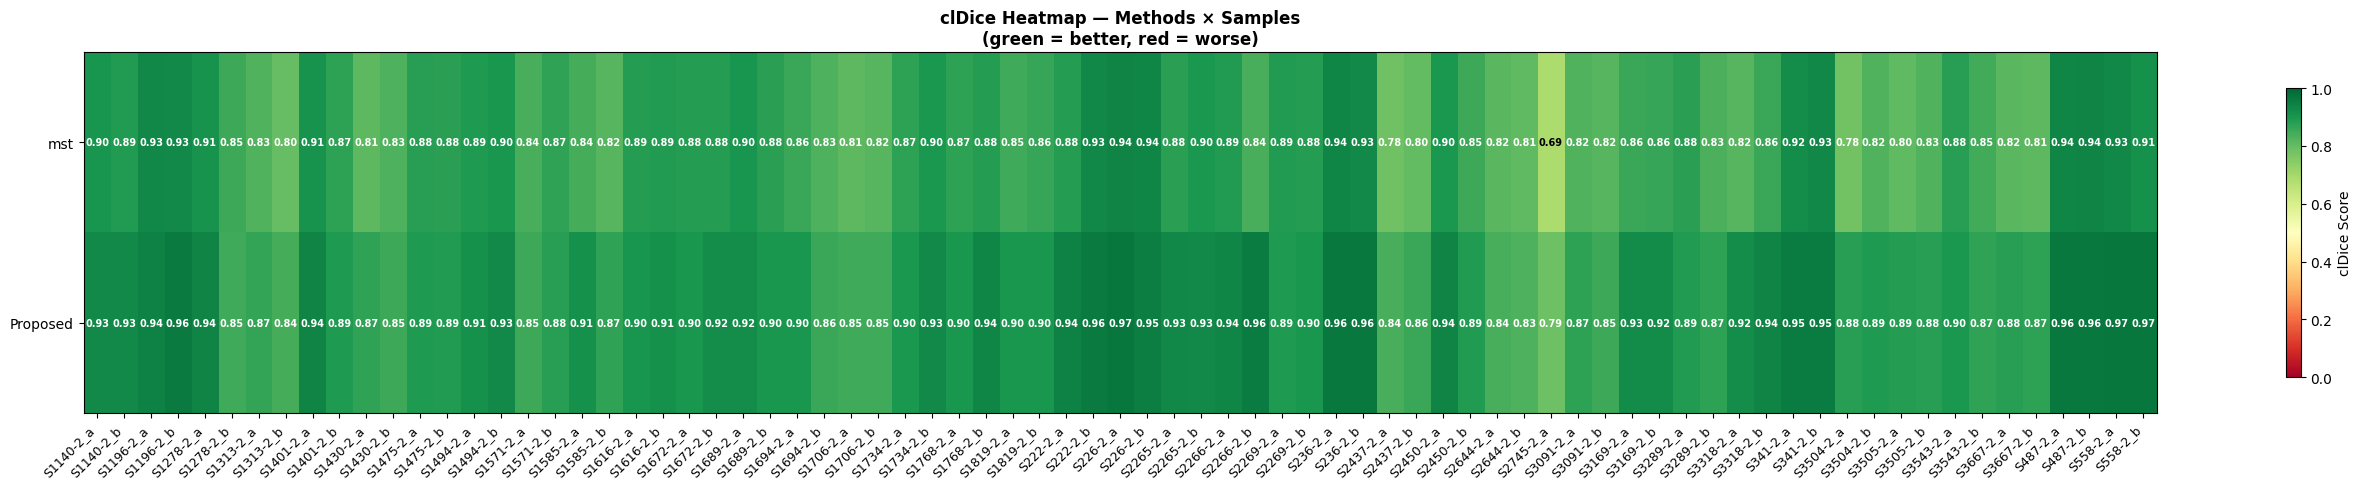

In [18]:
if not df_cld.empty:
    cld_samples = sorted(df_cld["sample"].unique())

    matrix = np.full((len(cld_methods), len(cld_samples)), np.nan)
    for i, m in enumerate(cld_methods):
        for j, s in enumerate(cld_samples):
            val = df_cld[(df_cld["method"] == m) & (df_cld["sample"] == s)]["cldice"]
            if not val.empty and not val.isna().all():
                matrix[i, j] = val.values[0]

    fig, ax = plt.subplots(figsize=(max(16, len(cld_samples) * 0.35), 3 + len(cld_methods)))
    im = ax.imshow(matrix, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)

    ax.set_xticks(range(len(cld_samples)))
    ax.set_xticklabels(cld_samples, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(cld_methods)))
    ax.set_yticklabels(cld_methods, fontsize=10)

    for i in range(len(cld_methods)):
        for j in range(len(cld_samples)):
            val = matrix[i, j]
            if not np.isnan(val):
                text_color = "white" if val < 0.35 or val > 0.75 else "black"
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=7, color=text_color, fontweight="bold")
            else:
                ax.text(j, i, "N/A", ha="center", va="center", fontsize=6, color="gray")

    plt.colorbar(im, ax=ax, label="clDice Score", shrink=0.8)
    ax.set_title("clDice Heatmap — Methods × Samples\n(green = better, red = worse)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

---
## Count Analysis — Predicted vs Ground Truth Fiber Crossings

Comparing predicted fiber crossing counts (`valid_count_pred`) against ground truth (`gt_count`).
Only samples that have GT count data are included.

### 9. Count MAE Summary

Samples with GT count: 77
            mean  median    std
method                         
Proposed   5.532     4.0  4.753
mst       12.649    11.0  8.407


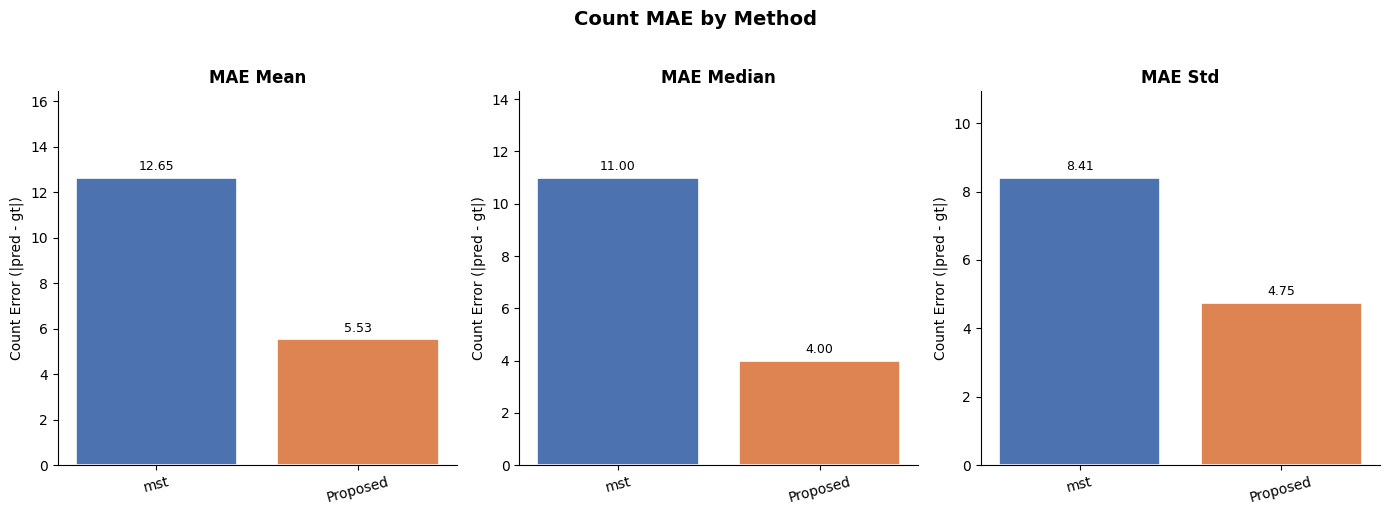

In [19]:
# Filter to samples with GT count
df_count = df[df["count_gt"].notna()].copy()
count_samples = sorted(df_count["sample"].unique())

count_summary = df_count.groupby("method")["count_error"].agg(["mean", "median", "std"]).round(3)
print(f"Samples with GT count: {len(count_samples)}")
print(count_summary)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
stats   = ["mean", "median", "std"]
titles  = ["MAE Mean", "MAE Median", "MAE Std"]

for ax, stat, title in zip(axes, stats, titles):
    vals = [count_summary.loc[m, stat] for m in methods]
    bars = ax.bar(methods, vals, color=[COLORS[m] for m in methods], edgecolor="white", linewidth=1.2)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Count Error (|pred - gt|)")
    ax.set_ylim(0, max(vals) * 1.3 if max(vals) > 0 else 1)
    ax.tick_params(axis="x", rotation=15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Count MAE by Method", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 10. Count Error Distribution (Box Plot)

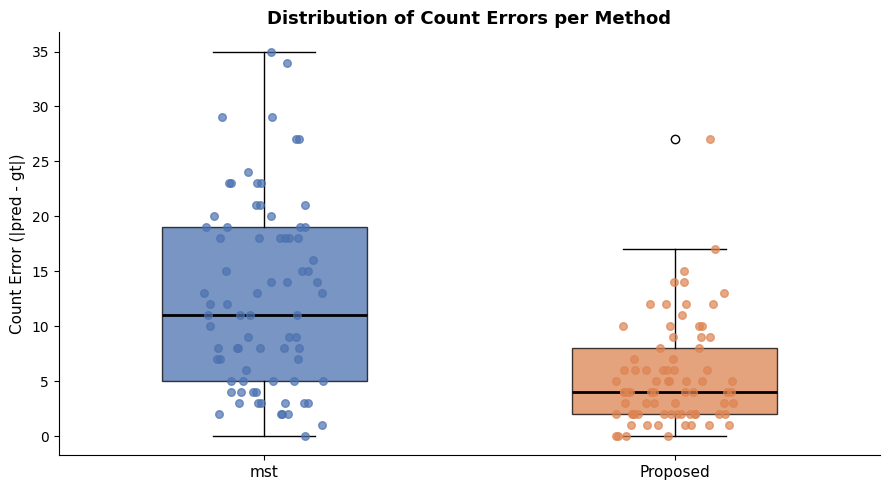

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))

plot_data = [df_count[df_count["method"] == m]["count_error"].values for m in methods]
bp = ax.boxplot(plot_data, patch_artist=True, notch=False, widths=0.5,
                medianprops=dict(color="black", linewidth=2))

for patch, method in zip(bp["boxes"], methods):
    patch.set_facecolor(COLORS[method])
    patch.set_alpha(0.75)

rng = np.random.default_rng(42)
for i, (vals, method) in enumerate(zip(plot_data, methods), start=1):
    jitter = rng.uniform(-0.15, 0.15, len(vals))
    ax.scatter(i + jitter, vals, color=COLORS[method], s=30, alpha=0.7, zorder=3)

ax.set_xticks(range(1, len(methods) + 1))
ax.set_xticklabels(methods, fontsize=11)
ax.set_ylabel("Count Error (|pred - gt|)", fontsize=11)
ax.set_title("Distribution of Count Errors per Method", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### 11. Predicted vs GT Count — Scatter Plot (per Method)

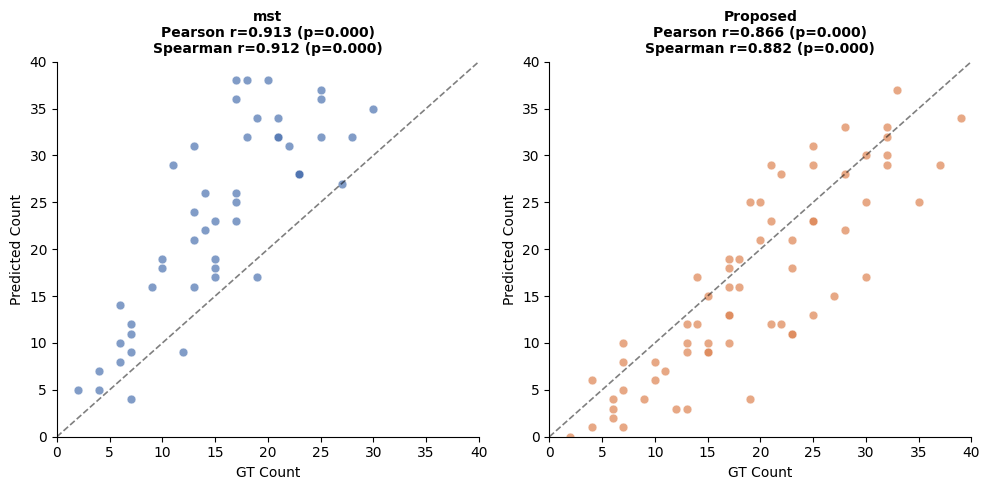

In [21]:
from scipy.stats import pearsonr, spearmanr

n_methods = len(methods)
fig, axes = plt.subplots(1, n_methods, figsize=(5 * n_methods, 5), sharey=False)
if n_methods == 1:
    axes = [axes]

for ax, method in zip(axes, methods):
    sub = df_count[df_count["method"] == method].dropna(subset=["count_pred", "count_gt"])
    gt   = sub["count_gt"].values
    pred = sub["count_pred"].values

    ax.scatter(gt, pred, color=COLORS[method], alpha=0.7, s=40, edgecolors="white", linewidths=0.5)

    # Perfect prediction line
    lim = max(gt.max(), pred.max()) * 1.1
    ax.plot([0, lim], [0, lim], "k--", linewidth=1.2, alpha=0.5, label="Perfect")

    # Pearson correlation
    if len(gt) >= 2:
        r, p = pearsonr(gt, pred)
        sr, sp = spearmanr(gt, pred)
        ax.set_title(
            f"{method}\nPearson r={r:.3f} (p={p:.3f})\nSpearman r={sr:.3f} (p={sp:.3f})",
            fontsize=10, fontweight="bold"
        )
    else:
        ax.set_title(method, fontsize=10, fontweight="bold")

    ax.set_xlabel("GT Count", fontsize=10)
    ax.set_ylabel("Predicted Count", fontsize=10)
    ax.set_xlim(0, 40)
    ax.set_ylim(0, 40)
    # ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# plt.suptitle("Predicted vs GT Count per Method", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Count Regression Metrics — R² and RMSE

           n      R2     RMSE      MAE
method                                
mst       77 -0.8166  15.1580  12.6494
Proposed  77  0.5817   7.2739   5.5325


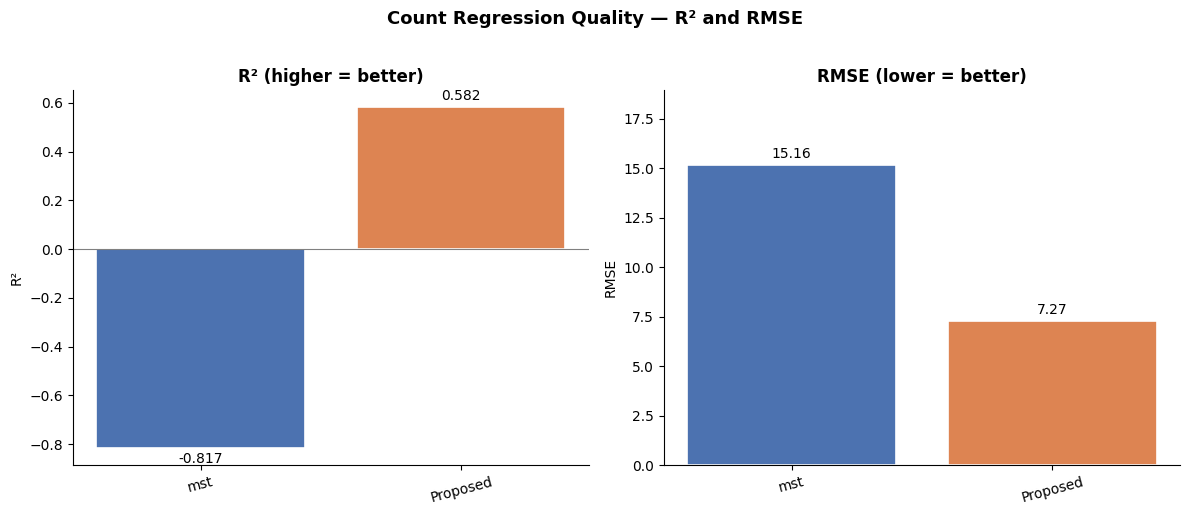

In [22]:
# R² and RMSE for Predicted vs GT Count per method
from sklearn.metrics import r2_score, mean_squared_error

rows = []
for method in methods:
    sub = df_count[df_count["method"] == method].dropna(subset=["count_pred", "count_gt"])
    gt   = sub["count_gt"].values
    pred = sub["count_pred"].values
    if len(gt) < 2:
        continue
    r2   = r2_score(gt, pred)
    rmse = np.sqrt(mean_squared_error(gt, pred))
    mae  = np.mean(np.abs(gt - pred))
    rows.append({"method": method, "n": len(gt), "R2": r2, "RMSE": rmse, "MAE": mae})

reg_df = pd.DataFrame(rows).set_index("method")
print(reg_df.round(4))

# Bar chart: R² and RMSE side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
vals = [reg_df.loc[m, "R2"] for m in reg_df.index]
bars = ax.bar(reg_df.index, vals, color=[COLORS[m] for m in reg_df.index],
              edgecolor="white", linewidth=1.2)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=10)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_title("R² (higher = better)", fontsize=12, fontweight="bold")
ax.set_ylabel("R²")
ax.tick_params(axis="x", rotation=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax = axes[1]
vals = [reg_df.loc[m, "RMSE"] for m in reg_df.index]
bars = ax.bar(reg_df.index, vals, color=[COLORS[m] for m in reg_df.index],
              edgecolor="white", linewidth=1.2)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=10)
ax.set_title("RMSE (lower = better)", fontsize=12, fontweight="bold")
ax.set_ylabel("RMSE")
ax.set_ylim(0, max(vals) * 1.25)
ax.tick_params(axis="x", rotation=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.suptitle("Count Regression Quality — R² and RMSE", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### 12. Per-Sample Count — Pred vs GT (Grouped Bar)

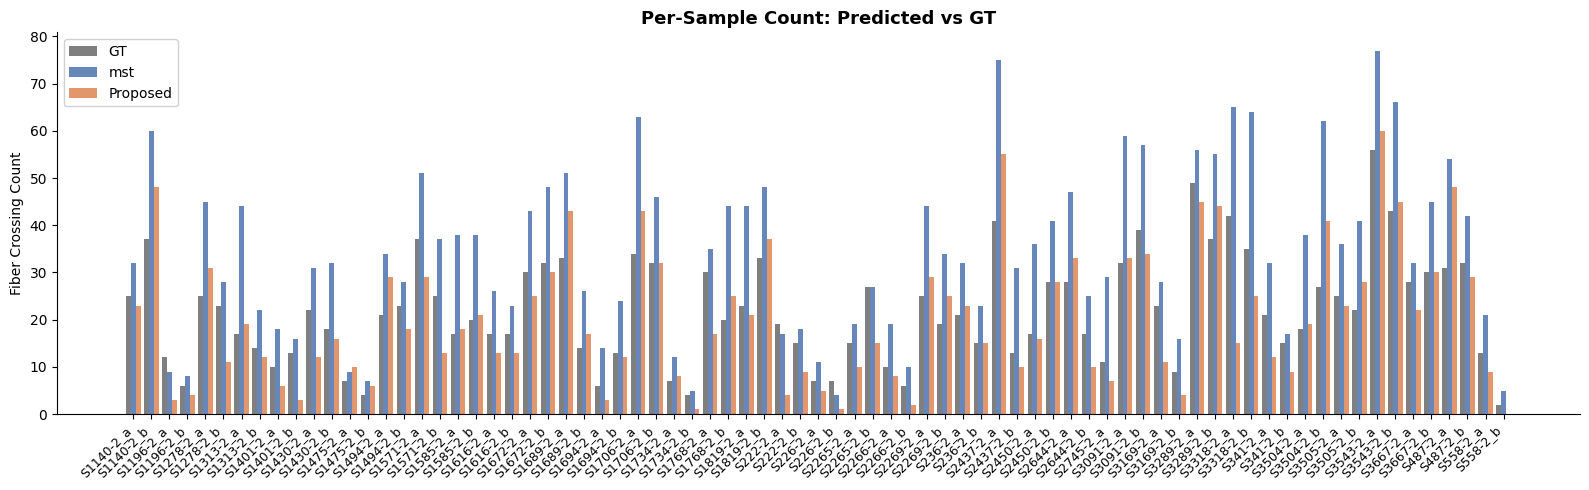

In [23]:
fig, ax = plt.subplots(figsize=(16, 5))

n_bars = len(methods) + 1  # +1 for GT
width  = 0.8 / n_bars
x      = np.arange(len(count_samples))

# Build GT lookup from all rows (GT is same across methods)
gt_by_sample = df_count.dropna(subset=["count_gt"]).groupby("sample")["count_gt"].first()
gt_vals = [gt_by_sample.get(s, 0) for s in count_samples]
ax.bar(x - width * (n_bars / 2 - 0.5), gt_vals, width, label="GT", color="black", alpha=0.5)

for i, method in enumerate(methods):
    sub = df_count[df_count["method"] == method].set_index("sample")
    vals = [sub.loc[s, "count_pred"] if s in sub.index else 0 for s in count_samples]
    offset = (i + 1 - n_bars / 2 + 0.5) * width
    ax.bar(x + offset, vals, width, label=method, color=COLORS[method], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(count_samples, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Fiber Crossing Count")
ax.set_title("Per-Sample Count: Predicted vs GT", fontsize=13, fontweight="bold")
ax.legend(loc="upper left", framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

---
## Combined Summary — Mean HD95, Mean clDice, Mean Count MAE

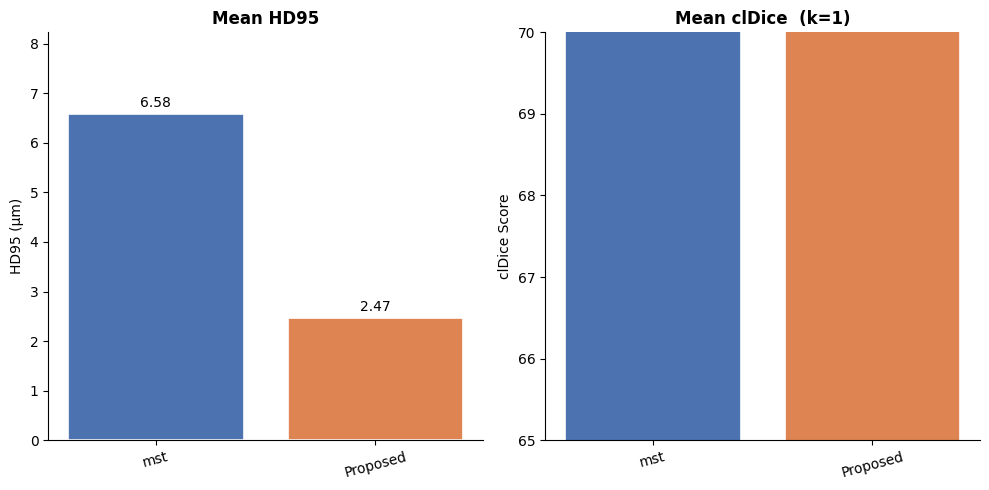

In [24]:
# Combined bar chart: Mean HD95 | Mean clDice | Mean Count MAE
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ── Mean HD95 (lower = better) ──
ax = axes[0]
hd95_vals = [df_hd95[df_hd95["method"] == m]["hd95"].mean() for m in methods]
bars = ax.bar(methods, hd95_vals, color=[COLORS[m] for m in methods],
              edgecolor="white", linewidth=1.2)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=10)
ax.set_title("Mean HD95", fontsize=12, fontweight="bold")
ax.set_ylabel("HD95 (μm)")
ax.set_ylim(0, max(hd95_vals) * 1.25)
ax.tick_params(axis="x", rotation=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── Mean clDice (higher = better) ──
ax = axes[1]
cld_vals = [df_cld[df_cld["method"] == m]["cldice"].mean() * 100 for m in methods]
bars = ax.bar(methods, cld_vals, color=[COLORS[m] for m in methods],
              edgecolor="white", linewidth=1.2)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=10)
ax.set_title("Mean clDice  (k=1)", fontsize=12, fontweight="bold")
ax.set_ylabel("clDice Score")
ax.set_ylim(65, 70)
ax.tick_params(axis="x", rotation=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()
